<a href="https://colab.research.google.com/github/subasiddarth70-prog/heart-desease-predictor-using-ml/blob/main/project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn shap lime xgboost lightgbm joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283913 sha256=9ef84db402c61624d5b5a8d37d16a550f85d406524920b63f48ca1fb15c1f6ff
  Stored in directory: /root/.cache/pip/wheels/7c/04/5c/157dc9106512a6c7a30653ec064490c94a49e0fc8f63d19ab9
Successfully built lime


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE

import shap
import lime
import lime.lime_tabular

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("/content/heart.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [5]:
from google.colab import files

uploaded = files.upload()

Saving ge.jpg to ge.jpg


In [6]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [7]:
df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


In [8]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nDataset information:")
df.info()

Number of rows: 1025
Number of columns: 14

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [10]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 723


In [11]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:")
print(df.shape)

Dataset shape after removing duplicates:
(302, 14)


In [12]:
possible_targets = [
    "target",
    "Target",
    "HeartDisease",
    "heartdisease",
    "heart_disease",
    "cardio",
    "output",
    "condition"
]

target_column = None

for column in possible_targets:
    if column in df.columns:
        target_column = column
        break

if target_column is None:
    print("Target column was not automatically detected.")
    print("Available columns:")
    print(df.columns.tolist())
else:
    print("Target column detected:", target_column)

Target column detected: target


target
1    164
0    138
Name: count, dtype: int64


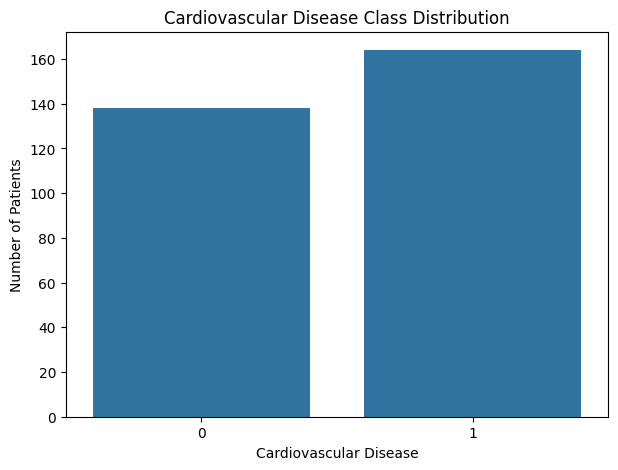

In [13]:
if target_column is not None:

    print(
        df[target_column].value_counts()
    )

    plt.figure(figsize=(7, 5))

    sns.countplot(
        x=target_column,
        data=df
    )

    plt.title(
        "Cardiovascular Disease Class Distribution"
    )

    plt.xlabel(
        "Cardiovascular Disease"
    )

    plt.ylabel(
        "Number of Patients"
    )

    plt.show()

In [14]:
missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Column": missing_values.index,
    "Missing Values": missing_values.values,
    "Missing Percentage":
        (missing_values.values / len(df)) * 100
})

missing_table

,Column,Missing Values,Missing Percentage
0,age,0,0.0
1,sex,0,0.0
2,cp,0,0.0
3,trestbps,0,0.0
4,chol,0,0.0
5,fbs,0,0.0
6,restecg,0,0.0
7,thalach,0,0.0
8,exang,0,0.0
9,oldpeak,0,0.0


In [15]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

for column in numeric_columns:

    if df[column].isnull().sum() > 0:

        df[column] = df[column].fillna(
            df[column].median()
        )

print(
    "Total missing values remaining:",
    df.isnull().sum().sum()
)

Total missing values remaining: 0


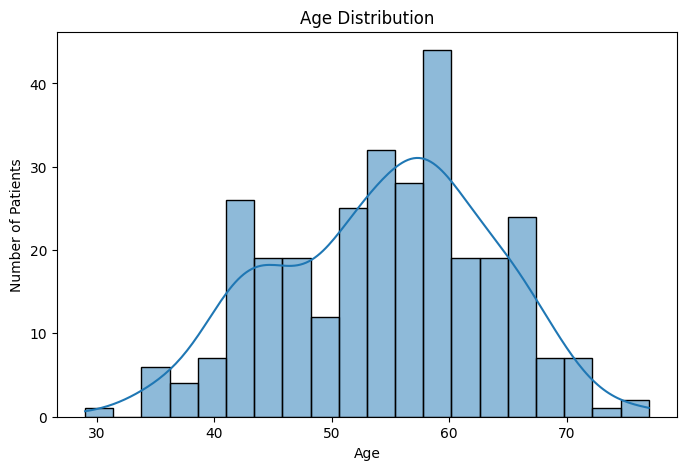

In [16]:
if "age" in df.columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        df["age"],
        bins=20,
        kde=True
    )

    plt.title("Age Distribution")

    plt.xlabel("Age")

    plt.ylabel("Number of Patients")

    plt.show()

else:
    print("Age column not found.")

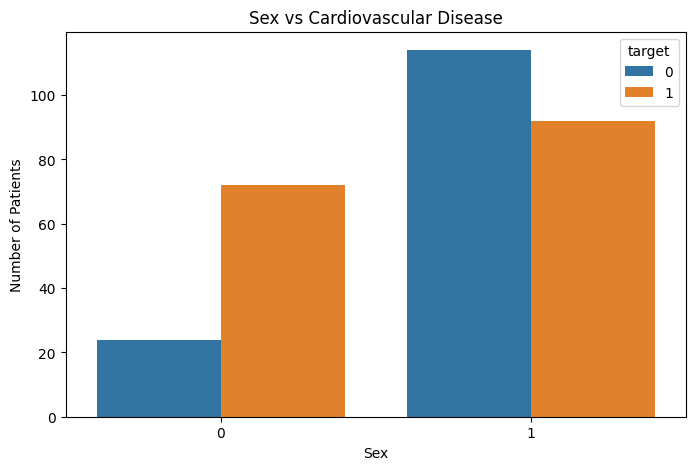

In [17]:
if "sex" in df.columns and target_column is not None:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        x="sex",
        hue=target_column,
        data=df
    )

    plt.title(
        "Sex vs Cardiovascular Disease"
    )

    plt.xlabel("Sex")

    plt.ylabel("Number of Patients")

    plt.show()

else:
    print("Required columns not found.")

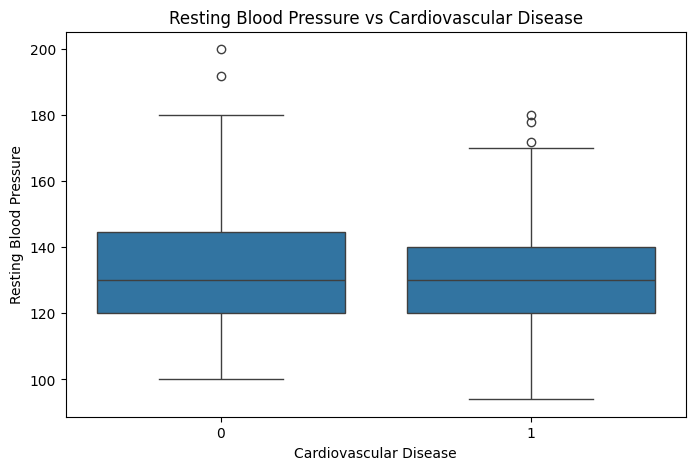

In [18]:
if "trestbps" in df.columns and target_column is not None:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=target_column,
        y="trestbps",
        data=df
    )

    plt.title(
        "Resting Blood Pressure vs Cardiovascular Disease"
    )

    plt.xlabel("Cardiovascular Disease")

    plt.ylabel("Resting Blood Pressure")

    plt.show()

else:
    print("trestbps column not found.")

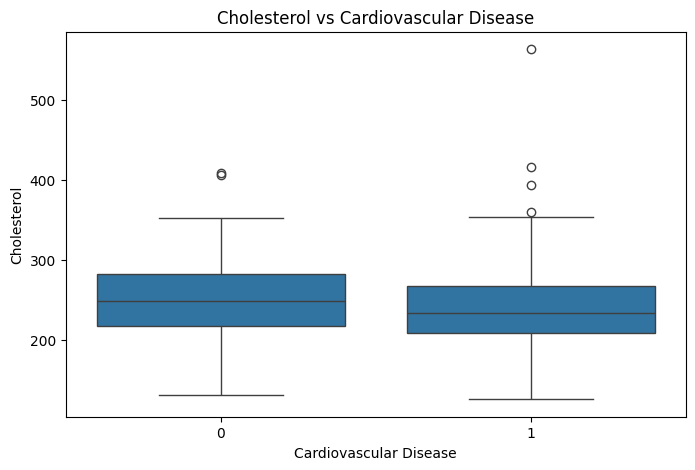

In [19]:
if "chol" in df.columns and target_column is not None:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=target_column,
        y="chol",
        data=df
    )

    plt.title(
        "Cholesterol vs Cardiovascular Disease"
    )

    plt.xlabel("Cardiovascular Disease")

    plt.ylabel("Cholesterol")

    plt.show()

else:
    print("chol column not found.")

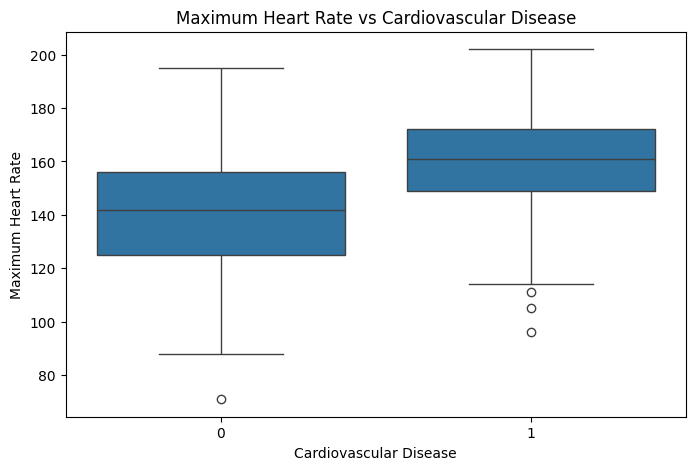

In [20]:
if "thalach" in df.columns and target_column is not None:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=target_column,
        y="thalach",
        data=df
    )

    plt.title(
        "Maximum Heart Rate vs Cardiovascular Disease"
    )

    plt.xlabel("Cardiovascular Disease")

    plt.ylabel("Maximum Heart Rate")

    plt.show()

else:
    print("thalach column not found.")

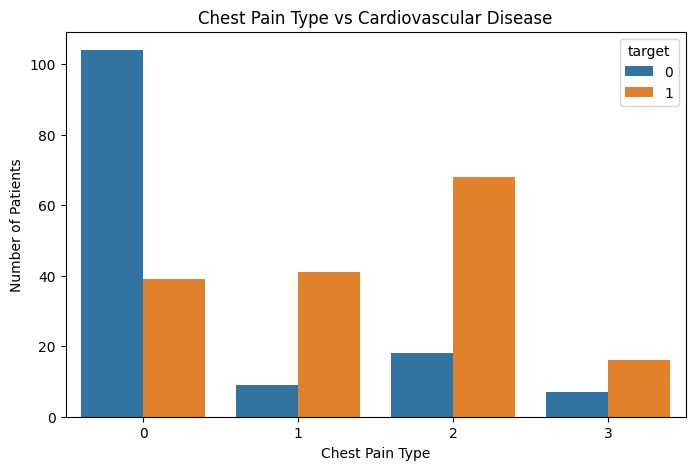

In [21]:
if "cp" in df.columns and target_column is not None:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        x="cp",
        hue=target_column,
        data=df
    )

    plt.title(
        "Chest Pain Type vs Cardiovascular Disease"
    )

    plt.xlabel("Chest Pain Type")

    plt.ylabel("Number of Patients")

    plt.show()

else:
    print("cp column not found.")

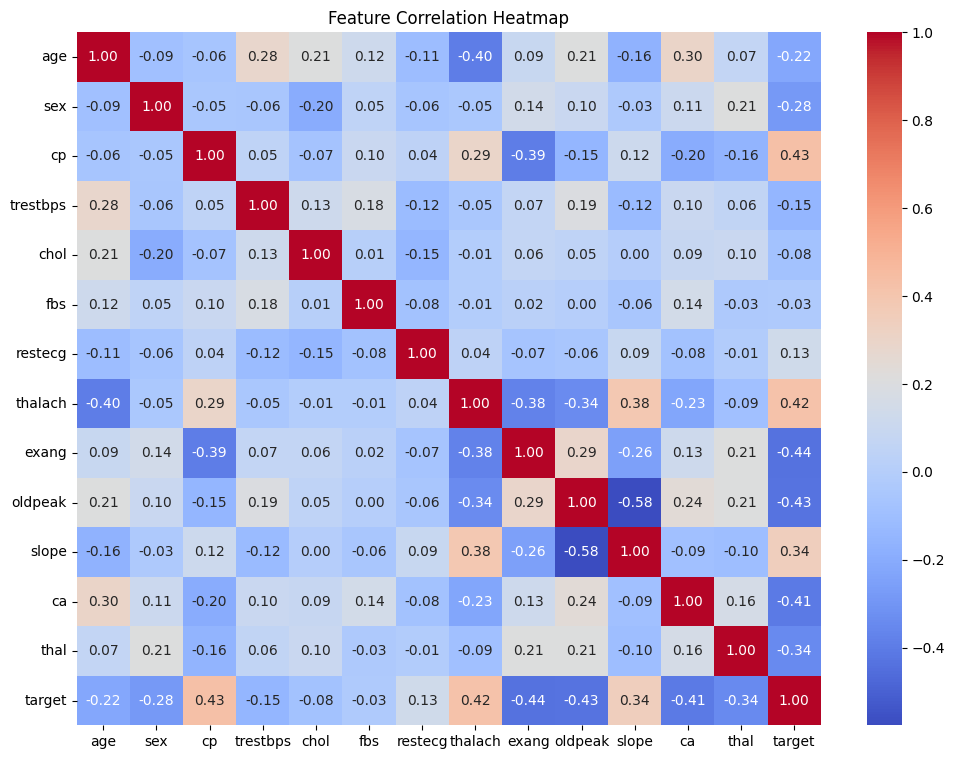

In [22]:
plt.figure(figsize=(12, 9))

correlation = df.corr(
    numeric_only=True
)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()


In [23]:
if (
    "trestbps" in df.columns
    and "chol" in df.columns
):

    df["bp_chol_ratio"] = (
        df["trestbps"] / df["chol"]
    )

if (
    "age" in df.columns
    and "thalach" in df.columns
):

    df["heart_rate_age_ratio"] = (
        df["thalach"] / df["age"]
    )

print("Feature engineering completed!")

df.head()

Feature engineering completed!


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,bp_chol_ratio,heart_rate_age_ratio
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0,0.589623,3.230769
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0,0.689655,2.924528
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0,0.833333,1.785714
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0,0.729064,2.639344
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0,0.469388,1.709677


In [24]:
if "age" in df.columns:

    df["age_group"] = pd.cut(
        df["age"],
        bins=[0, 40, 50, 60, 100],
        labels=[0, 1, 2, 3]
    )

    print(
        df[
            ["age", "age_group"]
        ].head()
    )

   age age_group
0   52         2
1   53         2
2   70         3
3   61         3
4   62         3


In [25]:
exclude_columns = []

if target_column is not None:
    exclude_columns.append(target_column)

# Remove age_group because it is categorical
if "age_group" in df.columns:
    exclude_columns.append("age_group")

feature_columns = [
    column
    for column in df.columns
    if column not in exclude_columns
    and pd.api.types.is_numeric_dtype(df[column])
]

print("Features selected:")
print(feature_columns)

X = df[feature_columns]

y = df[target_column]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features selected:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'bp_chol_ratio', 'heart_rate_age_ratio']

X shape: (302, 15)
y shape: (302,)


In [26]:
print("First 5 feature rows:")

display(X.head())

print("\nFirst 5 target values:")

display(y.head())

First 5 feature rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,bp_chol_ratio,heart_rate_age_ratio
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.589623,3.230769
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.689655,2.924528
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.833333,1.785714
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.729064,2.639344
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.469388,1.709677



First 5 target values:


,target
0,0
1,0
2,0
3,0
4,0


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    X_train.shape[0]
)

print(
    "Testing samples:",
    X_test.shape[0]
)

Training samples: 241
Testing samples: 61


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed!")

Feature scaling completed!


In [29]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=0.95
)

X_train_pca = pca.fit_transform(
    X_train_scaled
)

X_test_pca = pca.transform(
    X_test_scaled
)

print(
    "Original features:",
    X_train.shape[1]
)

print(
    "PCA components:",
    X_train_pca.shape[1]
)

print(
    "Explained variance:",
    round(
        pca.explained_variance_ratio_.sum(),
        4
    )
)

Original features: 15
PCA components: 12
Explained variance: 0.9685


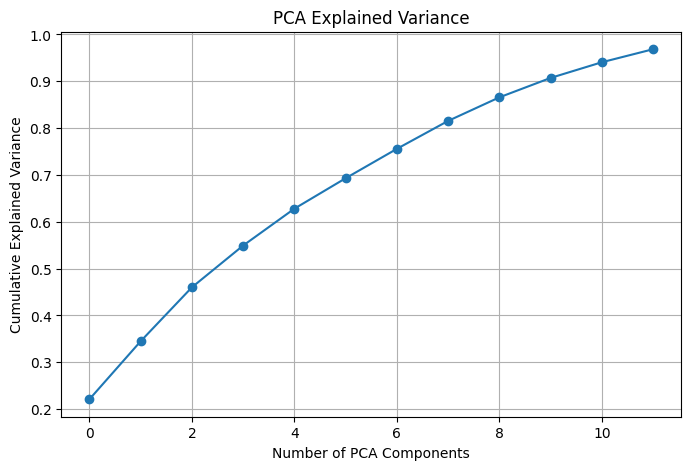

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker="o"
)

plt.xlabel(
    "Number of PCA Components"
)

plt.ylabel(
    "Cumulative Explained Variance"
)

plt.title(
    "PCA Explained Variance"
)

plt.grid()

plt.show()

Class distribution before SMOTE:
target
1    131
0    110
Name: count, dtype: int64


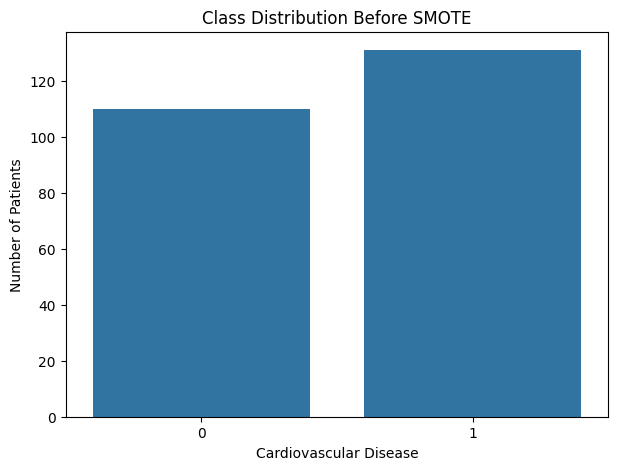

In [31]:
print("Class distribution before SMOTE:")

print(
    y_train.value_counts()
)

plt.figure(figsize=(7, 5))

sns.countplot(
    x=y_train
)

plt.title(
    "Class Distribution Before SMOTE"
)

plt.xlabel(
    "Cardiovascular Disease"
)

plt.ylabel(
    "Number of Patients"
)

plt.show()

In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    random_state=42
)

X_train_balanced, y_train_balanced = (
    smote.fit_resample(
        X_train_scaled,
        y_train
    )
)

print("Class distribution after SMOTE:")

print(
    pd.Series(
        y_train_balanced
    ).value_counts()
)

Class distribution after SMOTE:
target
1    131
0    131
Name: count, dtype: int64


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(
    X_train_balanced,
    y_train_balanced
)

rf_pred = rf_model.predict(
    X_test_scaled
)

print("Random Forest Results")

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Results
              precision    recall  f1-score   support

           0       0.75      0.75      0.75        28
           1       0.79      0.79      0.79        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [34]:
from sklearn.ensemble import ExtraTreesClassifier

et_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

et_model.fit(
    X_train_balanced,
    y_train_balanced
)

et_pred = et_model.predict(
    X_test_scaled
)

print("Extra Trees Results")

print(
    classification_report(
        y_test,
        et_pred
    )
)

Extra Trees Results
              precision    recall  f1-score   support

           0       0.78      0.75      0.76        28
           1       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61



In [35]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train_balanced,
    y_train_balanced
)

gb_pred = gb_model.predict(
    X_test_scaled
)

print("Gradient Boosting Results")

print(
    classification_report(
        y_test,
        gb_pred
    )
)

Gradient Boosting Results
              precision    recall  f1-score   support

           0       0.73      0.79      0.76        28
           1       0.81      0.76      0.78        33

    accuracy                           0.77        61
   macro avg       0.77      0.77      0.77        61
weighted avg       0.77      0.77      0.77        61



In [36]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("et", et_model),
        ("gb", gb_model)
    ],
    voting="soft"
)

voting_model.fit(
    X_train_balanced,
    y_train_balanced
)

voting_pred = voting_model.predict(
    X_test_scaled
)

print("Voting Ensemble Results")

print(
    classification_report(
        y_test,
        voting_pred
    )
)

Voting Ensemble Results
              precision    recall  f1-score   support

           0       0.74      0.71      0.73        28
           1       0.76      0.79      0.78        33

    accuracy                           0.75        61
   macro avg       0.75      0.75      0.75        61
weighted avg       0.75      0.75      0.75        61



In [37]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

models = {
    "Random Forest": rf_model,
    "Extra Trees": et_model,
    "Gradient Boosting": gb_model,
    "Voting Ensemble": voting_model
}

results = []

for name, model in models.items():

    prediction = model.predict(
        X_test_scaled
    )

    probability = model.predict_proba(
        X_test_scaled
    )[:, 1]

    results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                prediction
            ),

        "Precision":
            precision_score(
                y_test,
                prediction,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                prediction,
                zero_division=0
            ),

        "F1 Score":
            f1_score(
                y_test,
                prediction,
                zero_division=0
            ),

        "ROC AUC":
            roc_auc_score(
                y_test,
                probability
            )
    })

results_df = pd.DataFrame(
    results
)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.770492,0.787879,0.787879,0.787879,0.849567
1,Extra Trees,0.786885,0.794118,0.818182,0.805970,0.858225
2,Gradient Boosting,0.770492,0.806452,0.757576,0.781250,0.832251
3,Voting Ensemble,0.754098,0.764706,0.787879,0.776119,0.852814


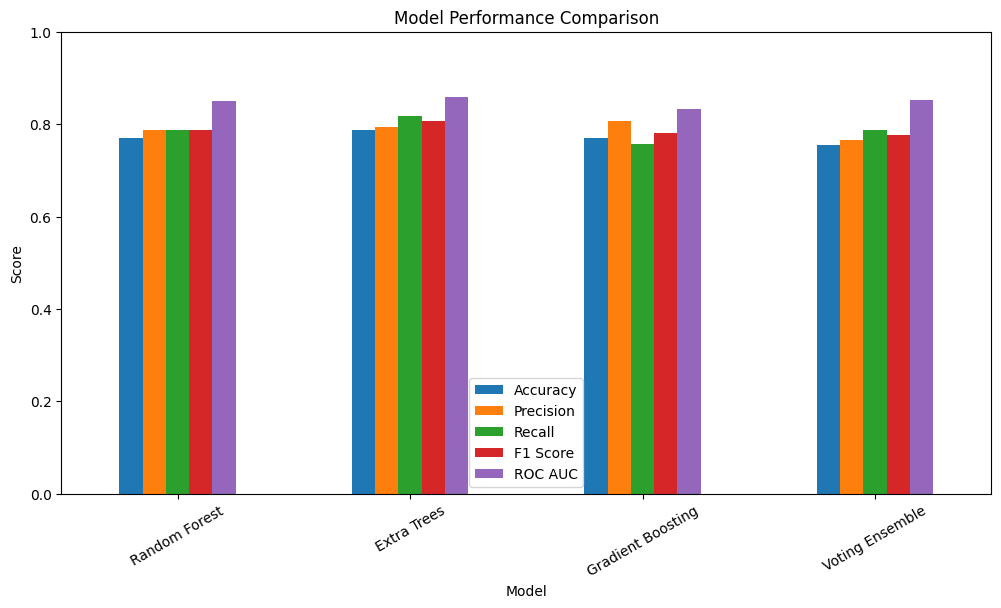

In [38]:
results_df.set_index(
    "Model"
)[
    [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ]
].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(
    rotation=30
)

plt.show()

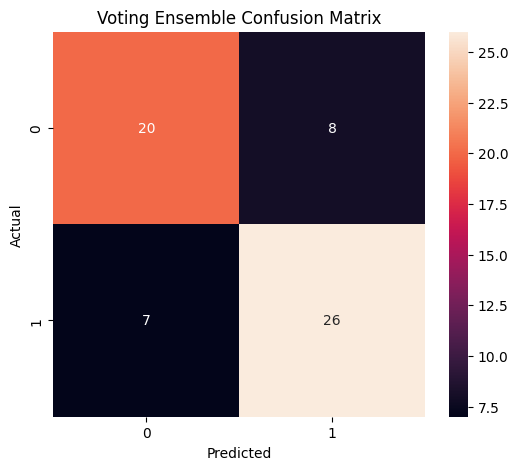

In [39]:
cm = confusion_matrix(
    y_test,
    voting_pred
)

plt.figure(
    figsize=(6, 5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Voting Ensemble Confusion Matrix"
)

plt.show()

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

automl_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=150,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=150,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=150,
            random_state=42
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingClassifier(
            random_state=42
        )
}

automl_results = []

for name, model in automl_models.items():

    model.fit(
        X_train_balanced,
        y_train_balanced
    )

    pred = model.predict(
        X_test_scaled
    )

    prob = model.predict_proba(
        X_test_scaled
    )[:, 1]

    automl_results.append({

        "Model": name,

        "Accuracy":
            accuracy_score(
                y_test,
                pred
            ),

        "Precision":
            precision_score(
                y_test,
                pred,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_test,
                pred,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_test,
                pred,
                zero_division=0
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                prob
            )
    })

automl_df = pd.DataFrame(
    automl_results
)

display(
    automl_df.sort_values(
        "ROC_AUC",
        ascending=False
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.786885,0.812500,0.787879,0.800000,0.869048
2,Extra Trees,0.786885,0.794118,0.818182,0.805970,0.859848
1,Random Forest,0.770492,0.787879,0.787879,0.787879,0.853896
4,Hist Gradient Boosting,0.737705,0.757576,0.757576,0.757576,0.832251
3,Gradient Boosting,0.754098,0.781250,0.757576,0.769231,0.813853


In [41]:
!pip install shap -q

import shap

print("SHAP installed successfully!")

SHAP installed successfully!


In [42]:
shap_explainer = shap.TreeExplainer(
    rf_model
)

shap_values = shap_explainer.shap_values(
    X_test_scaled
)

print("SHAP analysis completed!")

SHAP analysis completed!


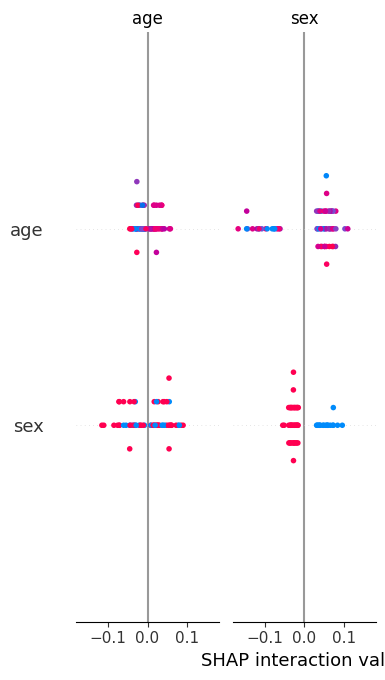

In [43]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_columns
)

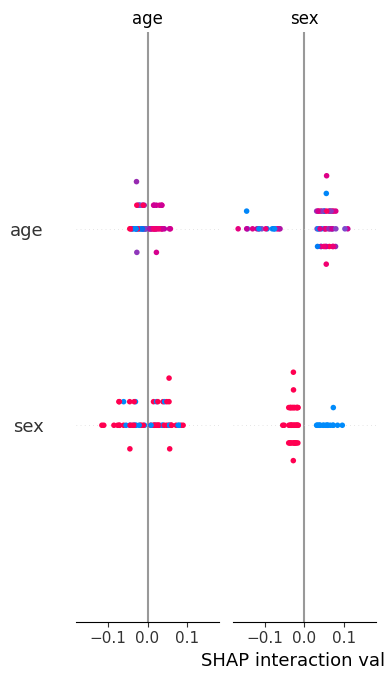

In [44]:
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_columns,
    plot_type="bar"
)

In [45]:
!pip install lime -q

import lime
import lime.lime_tabular

print("LIME installed successfully!")

LIME installed successfully!


In [46]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(

    X_train_scaled,

    feature_names=feature_columns,

    class_names=[
        "No Disease",
        "Disease"
    ],

    mode="classification",

    random_state=42
)

print("LIME explainer created!")

LIME explainer created!


In [47]:
lime_explanation = lime_explainer.explain_instance(

    X_test_scaled[0],

    rf_model.predict_proba,

    num_features=10
)

lime_explanation.show_in_notebook()

In [48]:
if "sex" in X_test.columns:

    fairness_data = X_test.copy()

    fairness_data["actual"] = y_test.values

    fairness_data["prediction"] = voting_pred

    fairness_results = []

    for sex_value in sorted(
        fairness_data["sex"].unique()
    ):

        group = fairness_data[
            fairness_data["sex"] == sex_value
        ]

        fairness_results.append({

            "Sex": sex_value,

            "Samples": len(group),

            "Actual Disease Rate":
                group["actual"].mean(),

            "Predicted Disease Rate":
                group["prediction"].mean(),

            "Recall":
                recall_score(
                    group["actual"],
                    group["prediction"],
                    zero_division=0
                )
        })

    fairness_df = pd.DataFrame(
        fairness_results
    )

    display(fairness_df)

else:

    print(
        "Sex column is not available for fairness analysis."
    )

,Sex,Samples,Actual Disease Rate,Predicted Disease Rate,Recall
0,0,18,0.722222,0.722222,0.846154
1,1,43,0.465116,0.488372,0.750000


In [49]:
importance = pd.DataFrame({

    "Feature": feature_columns,

    "Importance":
        rf_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
2,cp,0.162308
12,thal,0.111327
11,ca,0.097395
7,thalach,0.090303
14,heart_rate_age_ratio,0.084484
9,oldpeak,0.073838
0,age,0.067218
4,chol,0.061414
8,exang,0.056511
13,bp_chol_ratio,0.054520


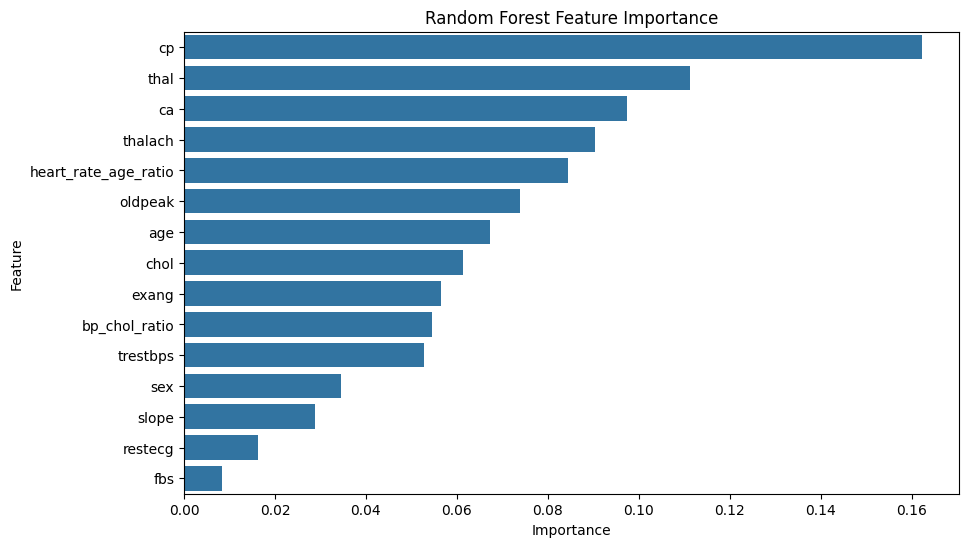

In [50]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")

plt.ylabel("Feature")

plt.show()

In [51]:
def predict_patient(patient_values):

    patient_df = pd.DataFrame(
        [patient_values],
        columns=feature_columns
    )

    patient_scaled = scaler.transform(
        patient_df
    )

    prediction = voting_model.predict(
        patient_scaled
    )[0]

    probability = voting_model.predict_proba(
        patient_scaled
    )[0][1]

    if probability < 0.30:
        risk = "Lower predicted risk"

    elif probability < 0.60:
        risk = "Intermediate predicted risk"

    else:
        risk = "Higher predicted risk"

    return prediction, probability, risk

In [52]:
# Use the first patient from the test dataset

patient = X_test.iloc[0].tolist()

prediction, probability, risk = predict_patient(
    patient
)

print("=" * 50)

print("CARDIOVASCULAR RISK PREDICTION")

print("=" * 50)

print(
    "Predicted Class:",
    prediction
)

print(
    "Predicted Probability:",
    round(
        probability * 100,
        2
    ),
    "%"
)

print(
    "Risk Category:",
    risk
)

print("=" * 50)

print(
    "Note: This is an educational/research model, "
    "not a medical diagnosis."
)

CARDIOVASCULAR RISK PREDICTION
Predicted Class: 0
Predicted Probability: 10.49 %
Risk Category: Lower predicted risk
Note: This is an educational/research model, not a medical diagnosis.


In [53]:
def show_dashboard(patient_index=0):

    patient = X_test.iloc[
        patient_index
    ].tolist()

    prediction, probability, risk = (
        predict_patient(patient)
    )

    print("\n")
    print("=" * 60)
    print("       CARDIOVASCULAR HEALTHCARE DASHBOARD")
    print("=" * 60)

    print("\nPatient Input:")

    for feature, value in zip(
        feature_columns,
        patient
    ):

        print(
            f"{feature:25s}: {value}"
        )

    print("\n" + "-" * 60)

    print(
        "Predicted Class:",
        prediction
    )

    print(
        "Disease Probability:",
        round(
            probability * 100,
            2
        ),
        "%"
    )

    print(
        "Risk Category:",
        risk
    )

    print("=" * 60)

    print(
        "\nEducational/research use only."
    )

In [54]:
show_dashboard(5)



       CARDIOVASCULAR HEALTHCARE DASHBOARD

Patient Input:
age                      : 64.0
sex                      : 1.0
cp                       : 0.0
trestbps                 : 120.0
chol                     : 246.0
fbs                      : 0.0
restecg                  : 0.0
thalach                  : 96.0
exang                    : 1.0
oldpeak                  : 2.2
slope                    : 0.0
ca                       : 1.0
thal                     : 2.0
bp_chol_ratio            : 0.4878048780487805
heart_rate_age_ratio     : 1.5

------------------------------------------------------------
Predicted Class: 0
Disease Probability: 5.65 %
Risk Category: Lower predicted risk

Educational/research use only.


In [55]:
show_dashboard(10)



       CARDIOVASCULAR HEALTHCARE DASHBOARD

Patient Input:
age                      : 71.0
sex                      : 0.0
cp                       : 2.0
trestbps                 : 110.0
chol                     : 265.0
fbs                      : 1.0
restecg                  : 0.0
thalach                  : 130.0
exang                    : 0.0
oldpeak                  : 0.0
slope                    : 2.0
ca                       : 1.0
thal                     : 2.0
bp_chol_ratio            : 0.41509433962264153
heart_rate_age_ratio     : 1.8309859154929577

------------------------------------------------------------
Predicted Class: 1
Disease Probability: 89.45 %
Risk Category: Higher predicted risk

Educational/research use only.


In [56]:
import joblib

joblib.dump(
    voting_model,
    "cardiovascular_model.pkl"
)

joblib.dump(
    scaler,
    "cardiovascular_scaler.pkl"
)

joblib.dump(
    feature_columns,
    "cardiovascular_features.pkl"
)

print(
    "All model files saved successfully!"
)

All model files saved successfully!
